In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import numpy as np
import xarray as xr

from causaldynamics.scm import create_scm_graph
from causaldynamics.plot import plot_scm
from causaldynamics.score import score
from causaldynamics.baselines import PCMCIPlus
from causaldynamics.baselines import FPCMCI
from causaldynamics.baselines import DYNOTEARS
from causaldynamics.baselines import VARLiNGAM
from causaldynamics.baselines import NGC_LSTM
from causaldynamics.baselines import TSCI
from causaldynamics.baselines import CUTSPlus
# from causaldynamics.baselines import RCD
# from causaldynamics.baselines import GIN
# from causaldynamics.baselines import GRASP
from causaldynamics.baselines import TCDF

# DYNOTEARS / FPCMCI + not sure about PCMCIPlus + VARLiNGAM

from tqdm import tqdm
from pathlib import Path
import torch

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt 

In [3]:
from causaldynamics.baselines import PICABU, StructuredLowRankDiscovery, StructuredODEDiscovery

In [6]:
# Once you have the dataset, either generated or downloaded
# Notice that the dataset has `time_series` and `adjacency_matrix` variables.
DATA_DIR = Path("../data/simple/noise=0.00_confounder=False/data")  # (you can change this to your own path)
ds = xr.open_dataset(DATA_DIR / "Rossler_N10_T1000.nc")

timeseries = ds['time_series'].to_numpy().transpose(1, 0, 2) # shape of (N, T, D)
adj_matrix = ds['adjacency_matrix'].to_numpy()


In [7]:
adj_matrix

array([[0, 1, 1],
       [1, 1, 0],
       [1, 0, 1]])

In [16]:
timeseries_stacked = timeseries[:, :, None]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tau_max = 1 # i.e. no delay 

## Estimate adjacency matrix
lowrank_adj_matrix = []

for x in [timeseries[:, :, None][2]]:
    lowrank_model = StructuredODEDiscovery(
        coupled=False,
        t = tau_max,
        n = 3,
        L_lipschitz = 1, 
        is_lipschitz = False,
        hidden_dim = 32, 
        n_layers = 2,
        device = device,
    )
    trained_model, mask = lowrank_model.run(X=torch.tensor(x).to(device), l0_l1_l2='l0', th=0.5, lr=0.001, lambda_grad=100, lambda_m = 0.001, n_inner_min_sparse = 100, batch_size=32, n_inner=4_000, patience = 500)
    lowrank_adj_matrix.append(mask.detach().cpu().numpy())
#     lowrank_S_matrix.append(copy.deepcopy(lowrank_model.model.S))



Dimensions: N=3, T=1
Number of NaN values in X: False
Number of NaN values after normalization in X: False
Constant dimensions in X: (tensor([], device='cuda:0', dtype=torch.int64),)
X_t_all.shape: torch.Size([999, 1, 3])
X_last_all.shape: torch.Size([999, 1, 3])
  → stopping inner loop at step 2158 after 500 no-improve steps (best=0.001893, current=0.002110)
recon=0.0013  |M|_1=5.996  grad_penalty=0.0000  


In [19]:
adj_matrix

array([[0, 1, 1],
       [1, 1, 0],
       [1, 0, 1]])

In [20]:
lowrank_adj_matrix

[array([[[1.0538487e-06, 9.9900323e-01, 9.9843401e-01],
         [9.9895751e-01, 1.0490623e-05, 9.9790907e-01],
         [9.9818748e-01, 1.3264831e-06, 9.9836975e-01]]], dtype=float32)]

In [21]:
x = torch.tensor(x).to(device)
x = x - x.mean(dim=0, keepdim=True)
x = x / (x.std(dim=0, keepdim=True) + 1e-8) # Small fix


In [22]:
((trained_model.infer(x[:-1]) - (x[1:] - x[:-1]))**2).sum(2).mean()

tensor(0.0035, device='cuda:0')

In [23]:
import torch.nn.functional as F

F.mse_loss(trained_model.infer(x[:-1]), x[1:] - x[:-1])

tensor(0.0012, device='cuda:0')

In [24]:
input_train_data = x.detach().cpu().numpy()
prediction = (x[:-1] + trained_model.infer(x[:-1])).detach().cpu().numpy()

prediction = prediction[:, 0]
input_train_data = input_train_data[1:, 0]

print(((prediction - input_train_data)**2).mean())

0.0011817345


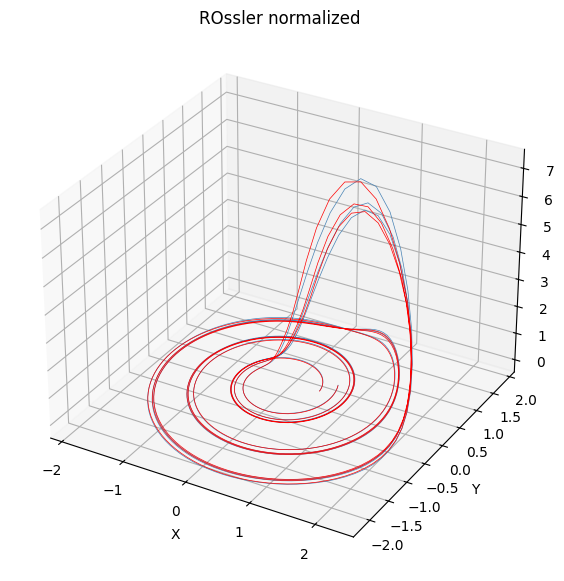

In [25]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(input_train_data[:, 0], input_train_data[:, 1], input_train_data[:, 2], lw=0.5, color='steelblue')
ax.plot(prediction[:, 0], prediction[:, 1], prediction[:, 2], lw=0.5, color='red')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("ROssler normalized")
plt.show()


In [26]:
trained_model.infer(x[0][None])

tensor([[[-0.0044,  0.0305, -0.0159]]], device='cuda:0')

In [27]:
test_timeseries = timeseries[1]

test_timeseries = test_timeseries - test_timeseries.mean(0)
test_timeseries = test_timeseries / (test_timeseries.std(0) + 1e-8) # Small fix


test_timeseries = torch.tensor(test_timeseries, device = "cuda")
full_predictions = torch.zeros(x.shape, device = "cuda") 
full_predictions[0] = test_timeseries[0]

for k in np.arange(1, 1000):
    initial_cond = full_predictions[k-1]
    diff = trained_model.infer(initial_cond[None])[0, 0]
    full_predictions[k] = initial_cond + diff
    
full_predictions = full_predictions[:, 0].detach().cpu().numpy()




In [23]:
# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot()
# ax.plot(input_train_data[:, 0], input_train_data[:, 1], lw=0.5, color='steelblue')
# ax.plot(full_predictions[1:, 0], full_predictions[1:, 1], lw=0.5, color='red')
# ax.set_xlabel("X"); ax.set_ylabel("Y");
# ax.set_title("Sprott Torus Attractor normalized first 2 dims")
# ax.set_xlim([-2.5, 2.5])
# ax.set_ylim([-2.5, 2.5])
# plt.show()
# plt.close()

In [30]:
test_timeseries = test_timeseries.detach().cpu().numpy()

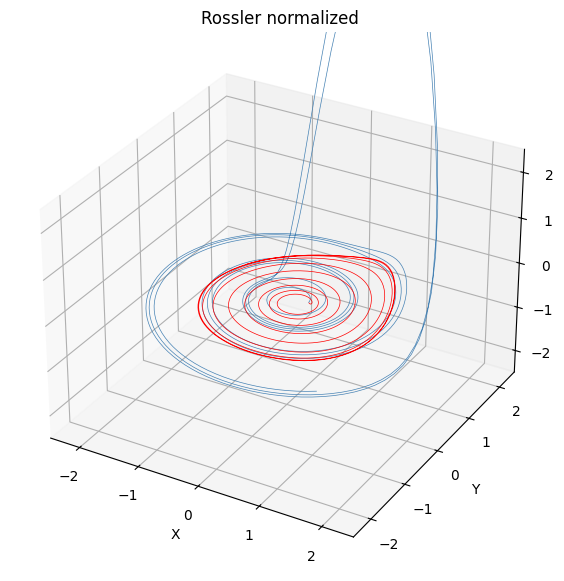

In [31]:
# test_timeseries = test_timeseries.detach().cpu().numpy()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(test_timeseries[:, 0], test_timeseries[:, 1], test_timeseries[:, 2], lw=0.5, color='steelblue')
ax.plot(full_predictions[1:, 0], full_predictions[1:, 1], full_predictions[1:, 2], lw=0.5, color='red')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("Rossler normalized")
ax.set_xlim([-2.5, 2.5])
ax.set_ylim([-2.5, 2.5])
ax.set_zlim([-2.5, 2.5])
plt.show()


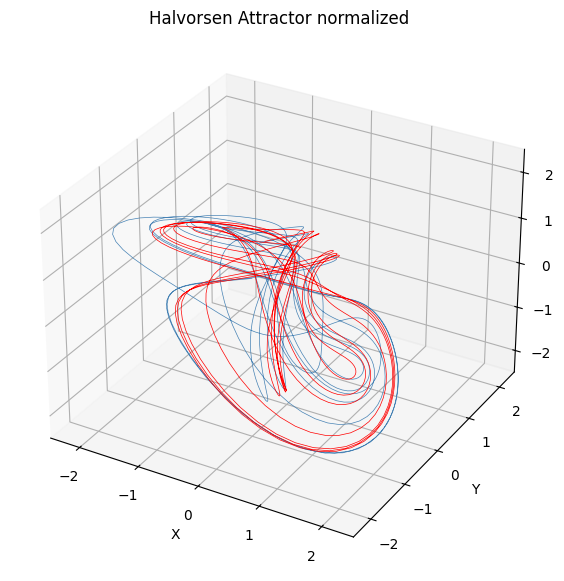

In [26]:
# test_timeseries = test_timeseries.detach().cpu().numpy()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(test_timeseries[:, 0], test_timeseries[:, 1], test_timeseries[:, 2], lw=0.5, color='steelblue')
ax.plot(full_predictions[1:, 0], full_predictions[1:, 1], full_predictions[1:, 2], lw=0.5, color='red')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("Halvorsen Attractor normalized")
ax.set_xlim([-2.5, 2.5])
ax.set_ylim([-2.5, 2.5])
ax.set_zlim([-2.5, 2.5])
plt.show()


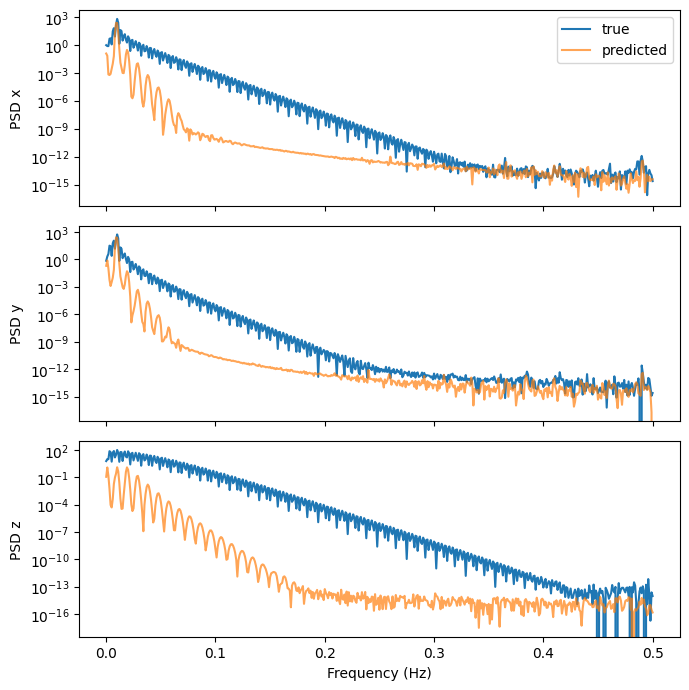

In [32]:
from scipy.signal import welch
import matplotlib.pyplot as plt

def compute_psd(traj, dt, nperseg=2048):
    """
    traj: (T, 3) array of [x, y, z]
    dt: fixed timestep between samples
    Returns freqs (Hz), psd (n_freqs, 3)
    """
    fs = 1.0 / dt
    nperseg = min(nperseg, traj.shape[0])
    freqs, psd0 = welch(traj[:, 0], fs=fs, nperseg=nperseg, detrend='constant')
    psd = np.zeros((len(freqs), traj.shape[1]))
    psd[:, 0] = psd0
    for i in range(1, traj.shape[1]):
        _, psd[:, i] = welch(traj[:, i], fs=fs, nperseg=nperseg, detrend='constant')
    return freqs, psd

freqs, psd_true = compute_psd(test_timeseries, 1)
_,     psd_pred = compute_psd(full_predictions, 1)

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)
for i, name in enumerate(['x', 'y', 'z']):
    axes[i].semilogy(freqs, psd_true[:, i], label='true')
    axes[i].semilogy(freqs, psd_pred[:, i], label='predicted', alpha=0.7)
    axes[i].set_ylabel(f'PSD {name}')
axes[0].legend()
axes[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
# plt.savefig('psd_comparison.png')
plt.show()
plt.close()

In [98]:
x[0]

tensor([[-1.5182, -0.1051,  0.6735]], device='cuda:0')

In [100]:
test_timeseries.std(0)

array([0.99999976, 1.0000001 , 0.9999995 ], dtype=float32)

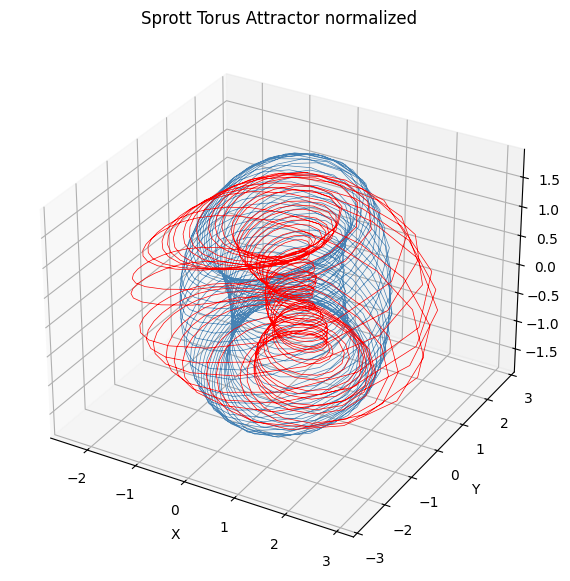

In [9]:
# Plot

train_timeseries = timeseries[0]
test_timeseries = timeseries[1]

test_timeseries = test_timeseries - test_timeseries.mean(0)
test_timeseries = test_timeseries / (test_timeseries.std(0) + 1e-8) # Small fix


train_timeseries = train_timeseries - train_timeseries.mean(0)
train_timeseries = train_timeseries / (train_timeseries.std(0) + 1e-8) # Small fix



fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(train_timeseries[:, 0], train_timeseries[:, 1], train_timeseries[:, 2], lw=0.5, color='steelblue')
ax.plot(test_timeseries[:, 0], test_timeseries[:, 1], test_timeseries[:, 2], lw=0.5, color='red')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("Sprott Torus Attractor normalized")
plt.show()


In [11]:
initial_conditions = train_timeseries[0]

full_predictions = torch.zeros(train_timeseries.shape, device = "cuda") 
full_predictions[0] = torch.tensor(initial_conditions).cuda()

for k in np.arange(1, 1000):
    initial_cond = full_predictions[k-1]
    diff = trained_model.infer(initial_cond[None, None])[0, 0]
    full_predictions[k] = full_predictions[k-1] + diff

In [24]:
initial_conditions = test_timeseries[0]

nextstep_predictions = torch.zeros(test_timeseries.shape, device = "cuda") 
nextstep_predictions[0] = torch.tensor(initial_conditions).cuda()

for k in np.arange(1, 1000):
    initial_cond = torch.tensor(test_timeseries[k-1]).cuda()
    diff = trained_model.infer(initial_cond[None, None])[0, 0]
    nextstep_predictions[k] = initial_cond + diff
    
nextstep_predictions = nextstep_predictions.detach().cpu().numpy()


In [25]:
nextstep_predictions - test_timeseries

array([[ 0.        ,  0.        ,  0.        ],
       [-0.04649395, -0.00198594,  0.11993301],
       [-0.05308491, -0.00811043,  0.12285149],
       ...,
       [-0.05739862, -0.02386922,  0.10209882],
       [-0.07839683, -0.04235262,  0.09108019],
       [-0.1088373 , -0.05828083,  0.06681967]], dtype=float32)

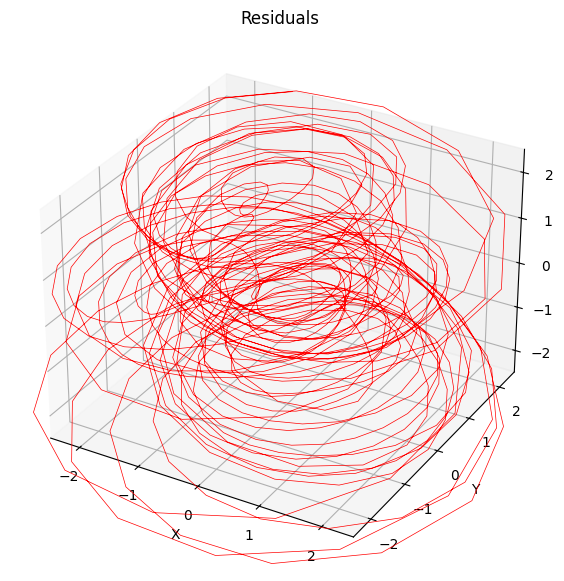

In [27]:

residuals = nextstep_predictions - train_timeseries

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# ax.plot(train_timeseries[:, 0], train_timeseries[:, 1], train_timeseries[:, 2], lw=0.5, color='steelblue')
# ax.plot(nextstep_predictions[:, 0], nextstep_predictions[:, 1], nextstep_predictions[:, 2], lw=0.5, color='red')
ax.plot(residuals[:, 0], residuals[:, 1], residuals[:, 2], lw=0.5, color='red')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")

ax.set_xlim([-2.5, 2.5])
ax.set_ylim([-2.5, 2.5])
ax.set_zlim([-2.5, 2.5])

ax.set_title("Residuals")
plt.show()


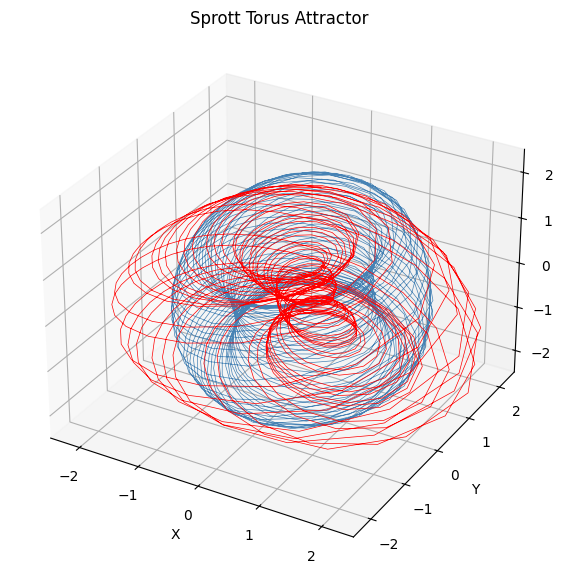

In [26]:

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(train_timeseries[:, 0], train_timeseries[:, 1], train_timeseries[:, 2], lw=0.5, color='steelblue')
ax.plot(nextstep_predictions[:, 0], nextstep_predictions[:, 1], nextstep_predictions[:, 2], lw=0.5, color='red')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")

ax.set_xlim([-2.5, 2.5])
ax.set_ylim([-2.5, 2.5])
ax.set_zlim([-2.5, 2.5])

ax.set_title("Sprott Torus Attractor")
plt.show()


In [12]:
full_predictions = full_predictions.detach().cpu().numpy()

In [13]:
full_predictions[-1]

array([ 0.27927557,  0.8391044 , -5.2809057 ], dtype=float32)

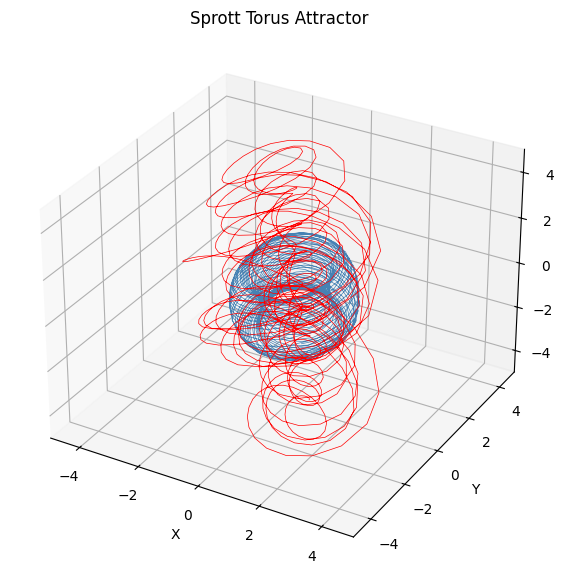

In [14]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(train_timeseries[:, 0], train_timeseries[:, 1], train_timeseries[:, 2], lw=0.5, color='steelblue')
ax.plot(full_predictions[:, 0], full_predictions[:, 1], full_predictions[:, 2], lw=0.5, color='red')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")

ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])
ax.set_zlim([-5, 5])

ax.set_title("Sprott Torus Attractor")
plt.show()
